In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
from neurovlm.models import load_model
from neurovlm.data import load_dataset, load_latent
from neurovlm.llm_summary import load_huggingface_model

import torch
import torch.nn as nn

## Q-Former

BLIP-2 introduces a **Querying Transformer (Q-Former)** as a lightweight bridge between a frozen image encoder and a frozen language model. Here we adapt the same idea for brain images:

| Component | Role |
|---|---|
| `latent_images` (d=384) | Frozen "brain image encoder" output |
| Q-Former | 32 learnable query tokens cross-attend to the image embedding, producing soft visual prompts |
| LLM (frozen) | Language model that receives `[visual prompts ‖ text tokens]` |

Only the Q-Former (~3M params) is trained; the LM stays frozen throughout.

In [2]:
# load text
df_pubs = load_dataset("pubmed_text")
df_pubs.head() # contains name, description columns, as well as train/test/val splits

,pmid,pmcid,doi,name,description,train,test,val
0,24911975,NaN,10.1371/journal.pone.0099222,Acute aerobic exercise increases cortical acti...,There is increasing evidence that acute aerobi...,True,False,False
1,22884992,NaN,10.1016/j.dcn.2012.07.001,Developmental differences in the neural correl...,Despite vast knowledge on the behavioral proce...,True,False,False
2,15722210,NaN,10.1016/j.cogbrainres.2004.09.011,The neural substrate of arithmetic operations ...,Recent functional neuroimaging studies have be...,True,False,False
3,21930137,NaN,10.1016/j.neuropsychologia.2011.09.006,Neural processing associated with comprehensio...,"In daily communication, we often use indirect ...",True,False,False
4,21930160,NaN,10.1097/gme.0b013e3181cc49e9,Postmenopausal hormone use impact on emotion p...,Despite considerable evidence for potential ef...,True,False,False


In [3]:
# load latent images, from: autoencoder.encoder(x)
autoencoder = load_model("autoencoder")
latent_images, pmids_images = load_latent('pubmed_images')

# filter text
df_pubs = df_pubs[df_pubs["pmid"].isin(pmids_images)]
df_pubs = df_pubs.sort_values(by="pmid")
assert (pmids_images == df_pubs['pmid']).all() # aligned
df_pubs.reset_index(inplace=True, drop=True)
text = (df_pubs["name"] + " [SEP] " + df_pubs["description"]).tolist()

In [4]:
# load LM
model, tokenizer = load_huggingface_model("Qwen/Qwen3-4B", device="cuda", dtype=torch.bfloat16)


Loading HuggingFace model: Qwen/Qwen3-4B
Note: First-time download may take several minutes...
Progress indicators will appear below:

Step 1/2: Loading tokenizer...
✓ Tokenizer loaded

Step 2/2: Loading model (this may take a while)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

✓ Model loaded successfully!
  Device: cuda:0
  Model size: Qwen3-4B



In [5]:
class QFormer(nn.Module):
    """
    Querying Transformer (Q-Former) that bridges latent brain images (d=384)
    and the token embedding space of a frozen language model.

    32 learnable query tokens attend (cross-attention) to the projected image
    embedding, then their output is projected into the LM's hidden dimension
    so they can be prepended to the text token embeddings as soft visual prompts.
    """

    def __init__(
        self,
        image_dim: int = 384,
        num_queries: int = 32,
        hidden_dim: int = 256,
        num_heads: int = 8,
        num_layers: int = 4,
        lm_dim: int = 1024,
    ):
        super().__init__()
        self.num_queries = num_queries

        # Learnable query tokens
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, hidden_dim))

        # Project image vector into Q-Former hidden space
        self.image_proj = nn.Linear(image_dim, hidden_dim)

        # Transformer decoder: queries (tgt) cross-attend to image memory (memory)
        layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=True,       # pre-norm for stability
        )
        self.transformer = nn.TransformerDecoder(layer, num_layers=num_layers)
        #self.norm = nn.LayerNorm(hidden_dim)

        # Project Q-Former output into LM embedding space
        self.to_lm = nn.Linear(hidden_dim, lm_dim)

    def forward(self, image_embeds: torch.Tensor) -> torch.Tensor:
        """
        Args:
            image_embeds: (batch, image_dim)  — latent brain image vectors
        Returns:
            (batch, num_queries, lm_dim)  — soft visual prompt tokens
        """
        batch = image_embeds.size(0)
        mem = self.image_proj(image_embeds).unsqueeze(1)   # (B, 1, hidden_dim)
        q   = self.query_tokens.expand(batch, -1, -1)      # (B, Q, hidden_dim)
        out = self.transformer(q, mem)                      # (B, Q, hidden_dim)
        #return self.to_lm(self.norm(out))                   # (B, Q, lm_dim)
        return self.to_lm(out)                   # (B, Q, lm_dim)

## Dataset & DataLoaders

In [6]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np

PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

class BrainTextDataset(Dataset):
    def __init__(self, images, texts, tokenizer, max_length=128):
        self.images = images
        # Pre-tokenize once — eliminates per-batch tokenization overhead
        enc = tokenizer(list(texts), truncation=True, max_length=max_length,
                        add_special_tokens=True)
        self.input_ids = [torch.tensor(ids) for ids in enc["input_ids"]]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.images[idx], self.input_ids[idx]

def collate_fn(batch):
    images, input_ids = zip(*batch)
    images    = torch.tensor(np.array(images), dtype=torch.float32)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_ID)
    attn_mask = (input_ids != PAD_ID).long()
    return images, input_ids, attn_mask

train_mask = df_pubs["train"].values
val_mask   = df_pubs["val"].values
test_mask  = df_pubs["test"].values
text_arr   = np.array(text)

train_ds = BrainTextDataset(latent_images[train_mask], text_arr[train_mask], tokenizer)
val_ds   = BrainTextDataset(latent_images[val_mask],   text_arr[val_mask],   tokenizer)
test_ds  = BrainTextDataset(latent_images[test_mask],  text_arr[test_mask],  tokenizer)

batch_size = 8
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True,
                          collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=True,
                          collate_fn=collate_fn, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=True,
                          collate_fn=collate_fn, num_workers=4, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 23894 | Val: 2987 | Test: 2987


## Training

In [11]:
device = next(model.parameters()).device
lm_dim = model.config.hidden_size

# Freeze LM — only Q-Former trains
for p in model.parameters():
    p.requires_grad = False

# Recompute LM activations during backward instead of storing them.
# Without this, the 4B LM stores 20-40GB of activations at train time.
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
model.train()  # required for gradient checkpointing hooks to fire

qformer = QFormer(
    image_dim=384, num_queries=16, hidden_dim=256,
    num_heads=8,   num_layers=4,   lm_dim=lm_dim,
).to(device)

qformer = torch.compile(qformer)

NUM_EPOCHS = 10
optimizer = torch.optim.AdamW(qformer.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

n_params = sum(p.numel() for p in qformer.parameters())
print(f"Q-Former trainable parameters: {n_params:,}")
print(f"LM hidden size: {lm_dim}, device: {device}")

Q-Former trainable parameters: 4,974,336
LM hidden size: 2560, device: cuda:0


In [8]:
from tqdm.auto import tqdm

def lm_loss(qformer, model, images, input_ids, attn_mask, device):
    images    = images.to(device, non_blocking=True)
    input_ids = input_ids.to(device, non_blocking=True)
    attn_mask = attn_mask.to(device, non_blocking=True)
    batch_size = images.size(0)

    with torch.autocast("cuda", dtype=torch.bfloat16):
        vis_tokens = qformer(images)                               # (B, Q, lm_dim)
        num_q = vis_tokens.size(1)

        with torch.no_grad():
            text_embeds = model.get_input_embeddings()(input_ids)  # (B, T, lm_dim)

        inputs_embeds = torch.cat([vis_tokens, text_embeds], dim=1)
        vis_mask  = torch.ones(batch_size, num_q, device=device, dtype=torch.long)
        full_mask = torch.cat([vis_mask, attn_mask], dim=1)
        vis_labels = torch.full((batch_size, num_q), -100, dtype=torch.long, device=device)
        labels     = torch.cat([vis_labels, input_ids], dim=1)

        return model(inputs_embeds=inputs_embeds, attention_mask=full_mask, labels=labels).loss

best_val_loss = float("inf")
history = {"train": [None], "val": []}

# initial val loss
val_loss = 0.0
with torch.inference_mode():
    for imgs, input_ids, attn_mask in tqdm(val_loader, total=len(val_loader)):
        val_loss += lm_loss(qformer, model, imgs, input_ids, attn_mask, device).item()
val_loss /= max(len(val_loader), 1)
history["val"].append(val_loss)
print(f"intial val {val_loss:.4f}")

# training loop
for epoch in range(NUM_EPOCHS):
    qformer.train()
    train_loss = 0.0
    for imgs, input_ids, attn_mask in tqdm(train_loader, total=len(train_loader)):
        optimizer.zero_grad()
        loss = lm_loss(qformer, model, imgs, input_ids, attn_mask, device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(qformer.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    qformer.eval()
    val_loss = 0.0
    with torch.inference_mode():
        for imgs, input_ids, attn_mask in val_loader:
            val_loss += lm_loss(qformer, model, imgs, input_ids, attn_mask, device).item()
    val_loss /= max(len(val_loader), 1)

    scheduler.step()
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(qformer.state_dict(), "qformer_best.pt")

    print(f"Epoch {epoch+1:3d} | train {train_loss:.4f} | val {val_loss:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f}")

  0%|          | 0/373 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


intial val 2.9693


  0%|          | 0/746 [00:00<?, ?it/s]

Epoch   1 | train 2.2564 | val 2.1844


...

Epoch   8 | train 2.1370 | val 2.1344


  0%|          | 0/746 [00:00<?, ?it/s]

Epoch   9 | train 2.1355 | val 2.1337


  0%|          | 0/746 [00:00<?, ?it/s]

AcceleratorError: CUDA error: unknown error
Search for `cudaErrorUnknown' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


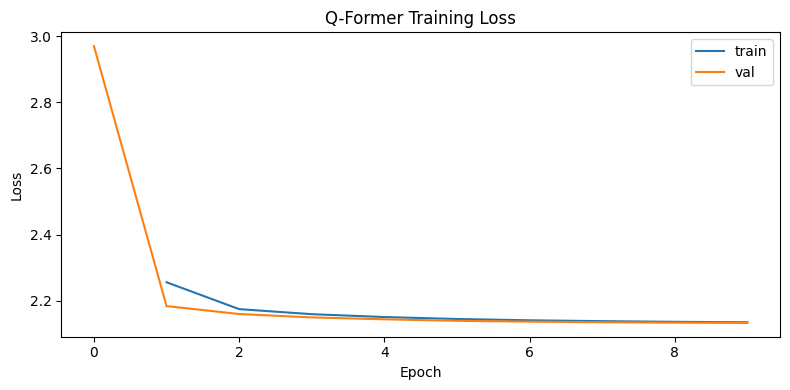

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Q-Former Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

## Inference

In [ ]:
import gzip
import pickle
import nibabel as nib
from neurovlm.data import data_dir, load_masker
from nilearn.image import resample_to_img

# load masker
masker = load_masker()

# load network atlases
with gzip.open(data_dir / "networks_arrays.pkl.gz", "rb") as f:
    networks = pickle.load(f)

network_imgs = []
for k in networks.keys():
    for a in networks[k].keys():
        network_imgs.append((k, a, nib.Nifti1Image(networks[k][a]["array"], affine=networks[k][a]["affine"])))

networks = [i for i in network_imgs if i[0] not in ["UKBICA", "HCPICA"]]

In [163]:

@torch.no_grad()
def generate_caption(qformer, model, tokenizer, image_embed,
                     prompt=None, max_new_tokens=256, device="cuda"):
    qformer.eval()
    img = torch.tensor(image_embed, dtype=torch.float32).unsqueeze(0).to(device)
    vis_tokens = qformer(img)                                         # (1, Q, lm_dim)

    if prompt:
        enc = tokenizer(prompt, return_tensors="pt").to(device)
        prompt_embeds = model.get_input_embeddings()(enc["input_ids"])
        inputs_embeds = torch.cat([vis_tokens, prompt_embeds], dim=1).to(model.dtype)
    else:
        inputs_embeds = vis_tokens.to(model.dtype)

    out_ids = model.generate(
        inputs_embeds=inputs_embeds,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.4,
        top_p=0.9,
        top_k=None,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out_ids[0], skip_special_tokens=True)

@torch.no_grad()
def generate_caption_instructed(qformer, model, tokenizer, image_embed, instruction=None, device="cuda"):

    instruction = (
        "Infer the main fMRI domain from the text.\n"
        "Choose the central neuroscience concept, not generic paper words.\n"
        "Ignore all study-specific details.\n"
        "Output exactly:\n"
        "Title: <1-3 word broad concept>\n"
        "Summary: <2-3 sentence textbook description of that concept only>\n"
        "Write from general neuroscience knowledge, not by paraphrasing the input.\n"
        "Include broad brain regions or networks only if clearly implied."
    )
    # Stage 1: no prompt — BOS only, let visual tokens drive generation
    raw = generate_caption(qformer, model, tokenizer, image_embed,
                           prompt=None, max_new_tokens=128, device=device)
    raw = raw.strip(" ").strip("\n")

    # Stage 2: rephrase with chat template
    messages = [
        {"role": "system", "content": instruction},
        {"role": "user",   "content": raw},
    ]
    ids = tokenizer.apply_chat_template(
        messages, return_tensors="pt",
        add_generation_prompt=True,
        enable_thinking=False,
    ).to(device)
    out = model.generate(
        ids,
        max_new_tokens=256,
        do_sample=False,
        temperature=None,
        top_p=None,
        top_k=None,
        pad_token_id=tokenizer.eos_token_id,
    )
    return raw, tokenizer.decode(out[0][ids.shape[-1]:], skip_special_tokens=True)

In [164]:
# Load best Q-Former checkpoint
qformer.load_state_dict(torch.load("qformer_best.pt", map_location=device))

<All keys matched successfully>

In [165]:
[l for i, l in enumerate(label_map) if i in [69, 23, 127, 107, 137, 21, 94, 17]]

[('Visual2', 'visual'),
 ('Language', 'language'),
 ('Auditory', 'auditory'),
 ('DorsAttn', 'attention'),
 ('LateralSM', 'motor'),
 ('DefaultA', 'default_mode'),
 ('SalVentAttnB', 'cingulo_opercular'),
 ('ControlB', 'frontoparietal_control')]

In [166]:
label_map = [
 ('VIS-P', 'unknown'), # this is a precuneus mask
 ('CG-OP', 'cingulo_opercular'),
 ('DN-B', 'default_mode'),
 ('SMOT-B', 'motor'),
 ('AUD', 'auditory'),
 ('PM-PPr', 'motor'),
 ('dATN-B', 'attention'),
 ('SMOT-A', 'motor'),
 ('LANG', 'language'),
 ('FPN-B', 'frontoparietal_control'),
 ('FPN-A', 'frontoparietal_control'),
 ('dATN-A', 'attention'),
 ('VIS-C', 'visual'),
 ('SAL/PMN', 'cingulo_opercular'),
 ('DN-A', 'default_mode'),
 ('NONE', 'unknown'),
 ('Visual1', 'visual'),
 ('Visual2', 'visual'),
 ('Somatomotor', 'motor'),
 ('CingOperc', 'cingulo_opercular'),
 ('DorsAttn', 'attention'),
 ('Language', 'language'),
 ('FrontPar', 'frontoparietal_control'),
 ('Auditory', 'auditory'),
 ('Default', 'default_mode'),
 ('PostMulti', 'unknown'),
 ('VentMulti', 'unknown'),
 ('OrbitAffective', 'unknown'),
 ('Emo/Interoception1', 'unknown'),
 ('Emo/Interoception2', 'unknown'),
 ('Emo/Interoception3', 'unknown'),
 ('Emo/Interoception4', 'unknown'),
 ('Mot/Visspatial1', 'motor'),
 ('Mot/Visspatial2', 'motor'),
 ('Mot/Visspatial3', 'motor'),
 ('Mot/Visspatial4', 'motor'),
 ('Visual1', 'visual'),
 ('Visual2', 'visual'),
 ('Visual3', 'visual'),
 ('DivergentCog1', 'unknown'),
 ('DivergentCog3', 'unknown'),
 ('DivergentCog4', 'unknown'),
 ('DivergentCog5', 'unknown'),
 ('DivergentCog6', 'unknown'),
 ('medial frontal', 'frontoparietal_control'),
 ('frontoparietal', 'frontoparietal_control'),
 ('default mode', 'default_mode'),
 ('motor cortex', 'motor'),
 ('visual A', 'visual'),
 ('visual B', 'visual'),
 ('visual association', 'visual'),
 ('subcortical cerebellum', 'unknown'),
 ('AntSal', 'cingulo_opercular'),
 ('Auditory', 'auditory'),
 ('DorsalDMN', 'default_mode'),
 ('HighVisual', 'visual'),
 ('Language', 'language'),
 ('LECN', 'frontoparietal_control'),
 ('PostSal', 'cingulo_opercular'),
 ('Precuneus', 'default_mode'),
 ('PrimVisual', 'visual'),
 ('RECN', 'frontoparietal_control'),
 ('Sensorimotor', 'motor'),
 ('VentralDMN', 'default_mode'),
 ('Visuospatial', 'unknown'),
 ('Default', 'default_mode'),
 ('LatVis', 'visual'),
 ('FrontPar', 'frontoparietal_control'),
 ('MedVis', 'visual'),
 ('DorsAttn', 'attention'),
 ('Premotor', 'motor'),
 ('Language', 'language'),
 ('Salience', 'cingulo_opercular'),
 ('CingOperc', 'cingulo_opercular'),
 ('HandSM', 'motor'),
 ('FaceSM', 'motor'),
 ('Auditory', 'auditory'),
 ('AntMTL', 'unknown'),
 ('PostMTL', 'unknown'),
 ('ParMemory', 'unknown'),
 ('Context', 'unknown'),
 ('FootSM', 'motor'),
 ('Visual', 'visual'),
 ('VentAttn', 'unknown'), # focus on dorsal attention
 ('DorsalSM', 'motor'),
 ('VentralSM', 'motor'),
 ('MedPar', 'default_mode'),
 ('ParOcc', 'visual'),
 ('SCAN', 'frontoparietal_control'),
 ('Cingulo-Opercular', 'cingulo_opercular'),
 ('Effector-hand', 'motor'),
 ('Effector-mouth', 'motor'),
 ('Effector-foot', 'motor'),
 ('SM', 'motor'),
 ('LateralSM', 'motor'),
 ('ResponseOneHanded(1RESP)', 'motor'),
 ('ResponseTwoHanded(2RESP)', 'motor'),
 ('AuditoryAttentionResponse(AAR)', 'auditory'),
 ('AuditoryPrimarySensory(AUD)', 'auditory'),
 ('DMNNovel(DMNA)', 'default_mode'),
 ('DMNTraditional(DMNB)', 'default_mode'),
 ('FocusOnVisualFeatures(FoVF)', 'visual'),
 ('Initiation(INIT)', 'unknown'),
 ('Language(LN)', 'language'),
 ('MAIN', 'unknown'),
 ('MultipleDemand(MDN)', 'frontoparietal_control'),
 ('Re-evaluation(RE-EV)', 'frontoparietal_control'),
 ('DefaultA', 'default_mode'),
 ('DefaultB', 'default_mode'),
 ('DefaultC', 'default_mode'),
 ('Language', 'language'),
 ('ContA', 'frontoparietal_control'),
 ('ContB', 'frontoparietal_control'),
 ('ContC', 'frontoparietal_control'),
 ('SalVenAttnA', 'cingulo_opercular'),
 ('SalVenAttnB', 'cingulo_opercular'),
 ('DorsAttnA', 'attention'),
 ('DorsAttnB', 'attention'),
 ('Aud', 'auditory'),
 ('SomMotA', 'motor'),
 ('SomMotB', 'motor'),
 ('VisualA', 'visual'),
 ('VisualB', 'visual'),
 ('VisualC', 'visual'),
 ('TempPar', 'frontoparietal_control'),
 ('LimbicA', 'unknown'), # these are dlmpc and temporal lobe
 ('LimbicB', 'unknown'),
 ('SalVentAttnB', 'cingulo_opercular'),
 ('SalVentAttnA', 'cingulo_opercular'),
 ('VisPeri', 'visual'),
 ('VisCent', 'visual'),
 ('SomatomotorA', 'motor'),
 ('SomatomotorB', 'motor'),
 ('Sal/VenAttnA', 'cingulo_opercular'),
 ('Sal/VenAttnB', 'cingulo_opercular'),
 ('ControlC', 'frontoparietal_control'),
 ('ControlA', 'frontoparietal_control'),
 ('ControlB', 'frontoparietal_control'),
 ('Visual', 'visual'),
 ('Somatomotor', 'motor'),
 ('DorsAttn', 'attention'),
 ('Sal/VenAttn', 'cingulo_opercular'),
 ('Limbic', 'unknown'),
 ('Control', 'frontoparietal_control'),
 ('Default', 'default_mode')]

key_map_inv = {
    'Visual':'visual',
    'Motor': 'motor',
    'Auditory': 'auditory',
    'Language': 'language',
    'Attention': 'attention',
    'Frontoparietal Control': 'frontoparietal_control',
    'Cingulo-Opercular': 'cingulo_opercular',
    'Default Mode': 'default_mode'
}
key_map = {v: k for k, v in key_map_inv.items()}

mask = np.array([i[1] in key_map.keys() for i in label_map])
mask[[45, 61, 108, 109, 63, 14]] = False
df = pd.DataFrame(dict(
    label=np.array([i[1] for i, j in zip(label_map, mask) if j]),
    label_re=np.array([key_map[i[1]] for i, j in zip(label_map, mask) if j]),
), index=np.arange(len(mask))[mask])
# df = df[df["label"] == df["top"]].loc[lambda d: d.groupby("label")["score"].idxmax()]


df = df[df.index.isin([69, 23, 127, 107, 137, 21, 94, 17])]
imgs = [i[-1] for idx, i in enumerate(networks) if idx in df.index.values]
df

,label,label_re
17,visual,Visual
21,language,Language
23,auditory,Auditory
69,attention,Attention
94,motor,Motor
107,default_mode,Default Mode
127,cingulo_opercular,Cingulo-Opercular
137,frontoparietal_control,Frontoparietal Control


In [170]:
from tqdm.auto import tqdm
raws = []
preds = []
imgs = [networks[i][2] for i in list(df.index)]
for img in tqdm(imgs, total=len(imgs)):
    img_re = resample_to_img(img, masker.mask_img, interpolation="nearest")
    v = masker.transform(img_re)
    with torch.no_grad():
        v = autoencoder.encoder(torch.from_numpy(v).float()).numpy()
    raw, pred = generate_caption_instructed(qformer, model, tokenizer, v, device=device)
    raws.append(raw)
    preds.append(pred)
    print(raw)
    print()
    print(pred)
    print()

  0%|          | 0/8 [00:00<?, ?it/s]

The neural correlates of visual motion perception: a functional magnetic resonance imaging study of the human brain. [SEP] We have used functional magnetic resonance imaging (fMRI) to investigate the neural correlates of motion perception in the human brain. We studied the responses of the human brain to motion stimuli in the form of random dot motion. The stimuli were presented in a block design and the responses of the brain were recorded in the form of a blood oxygenation level-dependent (BOLD) signal. We found that the primary visual cortex (V1) responded to motion stimuli with a significant increase in BOLD signal. Furthermore, the motion stimuli elicited

Title: Visual Motion Processing  
Summary: Visual motion processing involves the brain's ability to detect and interpret movement in the visual field. The primary visual cortex (V1) is key in initial motion detection, while higher-order areas like the middle temporal cortex (MT) are involved in more complex motion analysis. This